In [ ]:
import random

import torch
from datasets import load_dataset

# import trl  # trl = Transformers Reinforcement Learning -> https://github.com/huggingface/trl
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from trl import SFTConfig, SFTTrainer

In [2]:
if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)

    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory

    print(f"GPU: {gpu_name}")
    print(
        f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB"
    )
    print(
        f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB"
    )
    print(
        f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB"
    )
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")
else:
    print("No CUDA GPU available")

GPU: NVIDIA A30
Total Memory:     25338.05 MB | 25.34 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      25338.05 MB | 25.34 GB


## Setup Base Model

In [3]:
MODEL_NAME = "Qwen/Qwen3-2B"
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto",  # put the model on the GPU
    attn_implementation="eager",  # could use flash_attention_2 but ran into issues... so stick with Eager for now
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [4]:
print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


## Dataset

In [8]:
dataset = load_dataset(
    "json", data_files="data/auto-data/fine_tune_examples.jsonl", split="train"
)
print(dataset)
dataset = dataset.train_test_split(test_size=0.2, shuffle=False, seed=42)
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 31988
})
DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 25590
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 6398
    })
})


In [ ]:
def get_random_sample(dataset):
    """Returns a random sample from the dataset."""
    random_idx = random.randint(0, len(dataset) - 1)
    return dataset[random_idx]

get_random_sample(dataset["train"])

### Try model with pipeline

In [10]:
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

easy_sample = {"role": "user", "content": "你在幹嘛呀"}
input_prompt = pipe.tokenizer.apply_chat_template(
    [easy_sample],  # pipeline tokenizer wants a list of inputs
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)

print(f"[INFO] This is the input prompt: {input_prompt}")

default_outputs = pipe(input_prompt, max_new_tokens=512)

print(f"[INFO] Output from {MODEL_NAME}:")
print()
print(default_outputs[0]["generated_text"][len(input_prompt) :])

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[INFO] This is the input prompt: <|im_start|>user
你在幹嘛呀<|im_end|>
<|im_start|>assistant
<think>

</think>




Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Output from Qwen/Qwen3-2B:

我在跟你聊天哦～有什么想聊的，或者需要帮忙的吗？😊



## Fine-tuning

In [11]:
torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512,
    packing=False,
    num_train_epochs=3,
    per_device_train_batch_size=1,  # Note: you can change this depending on the amount of VRAM your GPU has
    gradient_accumulation_steps=8,
    per_device_eval_batch_size=8,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",  # Note: if you try "adamw", you will get an error
    logging_steps=100,
    save_strategy="steps",
    save_steps=2000,
    eval_strategy="steps",
    eval_steps=2000,
    learning_rate=BASE_LEARNING_RATE,
    fp16= torch_dtype == torch.float16,
    bf16= torch_dtype == torch.bfloat16,
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none",
)

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


In [13]:
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
)

trainer.train()
trainer.save_model()

Tokenizing train dataset:   0%|          | 0/25590 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/25590 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/6398 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/6398 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
2000,1.570006,3.017849
4000,0.375877,3.414310
6000,0.237466,3.503541
8000,0.113299,3.763229


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

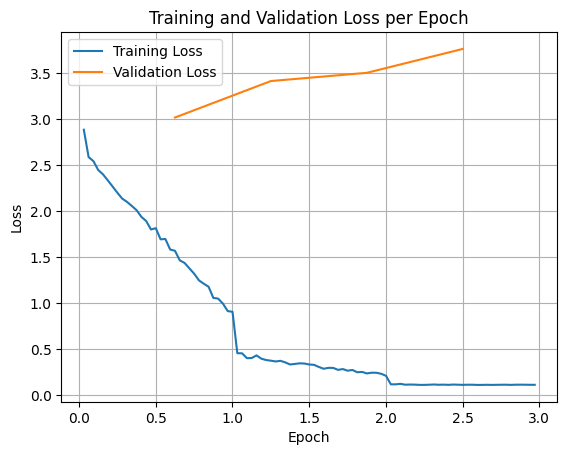

In [14]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Resuming training

In [ ]:
last_checkpoint = "output_dir/checkpoint-4000"  # replace with your last checkpoint folder
trainer.train(resume_from_checkpoint=last_checkpoint)

## Load the trained model

In [ ]:
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);